# BERT/SBERT Embedding Benchmark

**Mục tiêu:** So sánh performance giữa TF-IDF vs BERT embeddings trên các dataset nhỏ, ước lượng thời gian cho toàn dataset.

**Benchmark Sizes:**
- Dataset 5k/2k: 5000 train, 2000 test samples
- Dataset 20k/2k: 20000 train, 2000 test samples

**Metrics:**
- Embedding time (tính toán độ phức tạp)
- Model accuracy, precision, recall, F1
- Memory usage
- Time extrapolation cho 120k train (FULL)

In [1]:
%reload_ext autoreload
%autoreload 2

# Setup paths
from pathlib import Path
import sys
import os
import time
import numpy as np
import pandas as pd

def find_project_root(start=Path.cwd()):
    for p in [start] + list(start.parents):
        if (p / "modules").exists() and (p / "requirements.txt").exists():
            return p
    raise RuntimeError("Cannot find project root")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

# Import modules
from modules.config import Config
from modules.data_loader import load_data
from modules.bert_embed import build_sbert_embeddings, EmbedConfig, get_or_build_embeddings
from modules.tfidf_features import build_tfidf_features, save_features_npy
from modules.train_classical import get_model, train_eval
from modules.metrics import print_result, calculate_metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

PROJECT_ROOT: c:\Users\Admin\Documents\GitHub\MachineLearning_TextModule


## 1. Load and Prepare Sample Data

In [2]:
print("Loading full dataset from AG News...")
train_texts, train_labels, test_texts, test_labels, info = load_data("ag_news")
print(f"Full dataset - train: {len(train_texts)}, test: {len(test_texts)}")
print(f"Num classes: {info.num_classes}")
print()

# ===== Define benchmark sizes =====
BENCH_SIZES = {
    "5k/2k": {"train": 5000, "test": 2000},
    "20k/2k": {"train": 20000, "test": 2000}
}

# Prepare datasets for each benchmark size
datasets = {}
for name, size_dict in BENCH_SIZES.items():
    n_train = size_dict["train"]
    n_test = size_dict["test"]
    
    samples_train = train_texts[:n_train]
    labels_train = train_labels[:n_train]
    samples_test = test_texts[:n_test]
    labels_test = test_labels[:n_test]
    
    datasets[name] = {
        "train_texts": samples_train,
        "train_labels": np.array(labels_train),
        "test_texts": samples_test,
        "test_labels": np.array(labels_test)
    }
    print(f"{name}: train={len(samples_train)}, test={len(samples_test)}")

print(f"\n✓ Dataset preparation done")

Loading full dataset from AG News...
Full dataset - train: 120000, test: 7600
Num classes: 4

5k/2k: train=5000, test=2000
20k/2k: train=20000, test=2000

✓ Dataset preparation done


## 2. Generate BERT/SBERT Embeddings on Benchmark Datasets

Using `sentence-transformers/all-MiniLM-L6-v2` - một mô hình nhỏ và nhanh (384 dims).

In [3]:
print("=" * 70)
print("GENERATING SBERT EMBEDDINGS FOR BENCHMARK DATASETS")
print("=" * 70)

embeddings_results = {}
timing_results = {}

cfg = EmbedConfig(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    batch_size=32,
    normalize=True
)

for bench_name, dataset in datasets.items():
    print(f"\n{'='*70}")
    print(f"Benchmark: {bench_name}")
    print(f"{'='*70}")
    
    train_texts = dataset["train_texts"]
    test_texts = dataset["test_texts"]
    train_labels = dataset["train_labels"]
    test_labels = dataset["test_labels"]
    
    # ===== Generate embeddings =====
    print(f"\nGenerating embeddings for {len(train_texts)} train texts...")
    start_time = time.time()
    
    emb_train, emb_test = build_sbert_embeddings(
        train_texts,
        test_texts,
        cfg=cfg
    )
    
    embed_time = time.time() - start_time
    
    print(f"✓ Embedding generation done in {embed_time:.2f} seconds")
    print(f"  Train embeddings shape: {emb_train.shape}")
    print(f"  Test embeddings shape: {emb_test.shape}")
    print(f"  Embedding dim: {emb_train.shape[1]}")
    
    embeddings_results[bench_name] = {
        "train": emb_train,
        "test": emb_test,
        "train_labels": train_labels,
        "test_labels": test_labels
    }
    
    timing_results[bench_name] = {
        "n_train": len(train_texts),
        "n_test": len(test_texts),
        "total_samples": len(train_texts) + len(test_texts),
        "embed_time": embed_time,
        "time_per_sample": embed_time / (len(train_texts) + len(test_texts))
    }

print(f"\n✓ Embedding generation completed for all benchmarks")

GENERATING SBERT EMBEDDINGS FOR BENCHMARK DATASETS

Benchmark: 5k/2k

Generating embeddings for 5000 train texts...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/625 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

✓ Embedding generation done in 194.70 seconds
  Train embeddings shape: (20000, 384)
  Test embeddings shape: (2000, 384)
  Embedding dim: 384

✓ Embedding generation completed for all benchmarks


## 3. Save Embeddings to NPY Files

In [4]:
print("Saving embeddings to .npy files...")

cfg = Config()
cfg.bert_dir.mkdir(parents=True, exist_ok=True)

saved_files = {}

for bench_name, emb_data in embeddings_results.items():
    # Create benchmark subdirectory
    bench_dir = cfg.bert_dir / bench_name
    bench_dir.mkdir(parents=True, exist_ok=True)
    
    train_path = bench_dir / "bert_train.npy"
    test_path = bench_dir / "bert_test.npy"
    labels_train_path = bench_dir / "labels_train.npy"
    labels_test_path = bench_dir / "labels_test.npy"
    
    # Save embeddings
    np.save(train_path, emb_data["train"].astype(np.float32))
    np.save(test_path, emb_data["test"].astype(np.float32))
    
    # Save labels
    np.save(labels_train_path, emb_data["train_labels"])
    np.save(labels_test_path, emb_data["test_labels"])
    
    saved_files[bench_name] = {
        "train": str(train_path),
        "test": str(test_path),
        "labels_train": str(labels_train_path),
        "labels_test": str(labels_test_path)
    }
    
    print(f"✓ {bench_name}:")
    print(f"  Train: {train_path} ({np.prod(emb_data['train'].shape)} values)")
    print(f"  Test:  {test_path} ({np.prod(emb_data['test'].shape)} values)")

print(f"\n✓ All embeddings saved successfully")

Saving embeddings to .npy files...
✓ 5k/2k:
  Train: C:\Users\Admin\Documents\GitHub\MachineLearning_TextModule\features\bert\5k\2k\bert_train.npy (1920000 values)
  Test:  C:\Users\Admin\Documents\GitHub\MachineLearning_TextModule\features\bert\5k\2k\bert_test.npy (768000 values)
✓ 20k/2k:
  Train: C:\Users\Admin\Documents\GitHub\MachineLearning_TextModule\features\bert\20k\2k\bert_train.npy (7680000 values)
  Test:  C:\Users\Admin\Documents\GitHub\MachineLearning_TextModule\features\bert\20k\2k\bert_test.npy (768000 values)

✓ All embeddings saved successfully


## 4. Train Logistic Regression Baseline on BERT Embeddings

So sánh performance giữa các benchmark sizes.

In [5]:
print("=" * 70)
print("TRAINING BASELINE LOGISTIC REGRESSION ON BERT EMBEDDINGS")
print("=" * 70)

eval_results = {}

for bench_name, emb_data in embeddings_results.items():
    print(f"\n{'='*70}")
    print(f"Benchmark: {bench_name} - Training Logistic Regression")
    print(f"{'='*70}")
    
    X_train = emb_data["train"]
    y_train = emb_data["train_labels"]
    X_test = emb_data["test"]
    y_test = emb_data["test_labels"]
    
    # Create and train model
    print(f"\nTraining LogReg on {X_train.shape[0]} samples...")
    start_time = time.time()
    
    model = get_model(
        model_type="logistic_regression",
        C=1.0,
        max_iter=300
    )
    
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Evaluate
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    eval_results[bench_name] = {
        "train_time": train_time,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "y_pred": y_pred,
        "y_test": y_test
    }
    
    print(f"✓ Training completed in {train_time:.2f} seconds")
    print(f"\n  Metrics:")
    print(f"    Accuracy:  {acc:.4f}")
    print(f"    Precision: {prec:.4f}")
    print(f"    Recall:    {rec:.4f}")
    print(f"    F1-Score:  {f1:.4f}")

print(f"\n✓ Baseline training completed")

TRAINING BASELINE LOGISTIC REGRESSION ON BERT EMBEDDINGS

Benchmark: 5k/2k - Training Logistic Regression

Training LogReg on 5000 samples...
✓ Training completed in 8.10 seconds

  Metrics:
    Accuracy:  0.8740
    Precision: 0.8734
    Recall:    0.8740
    F1-Score:  0.8736

Benchmark: 20k/2k - Training Logistic Regression

Training LogReg on 20000 samples...
✓ Training completed in 68.73 seconds

  Metrics:
    Accuracy:  0.8930
    Precision: 0.8928
    Recall:    0.8930
    F1-Score:  0.8929

✓ Baseline training completed


## 5. Estimate Full Dataset Processing Time

In [6]:
print("=" * 70)
print("TIMING ANALYSIS & FULL DATASET EXTRAPOLATION")
print("=" * 70)

# Full dataset sizes
FULL_DATASET_SIZE = 120000  # Expected train size
FULL_TEST_SIZE = 7600      # Expected test size

print("\n📊 BENCHMARK TIMING RESULTS:")
print("-" * 70)

timing_summary = []

for bench_name, timing in timing_results.items():
    print(f"\n{bench_name}:")
    print(f"  Total samples: {timing['total_samples']:,}")
    print(f"  Embedding time: {timing['embed_time']:.2f} seconds")
    print(f"  Time per sample: {timing['time_per_sample']*1000:.3f} ms")
    
    timing_summary.append(timing)

# ===== Extrapolate to FULL dataset =====
print("\n\n" + "=" * 70)
print("📈 EXTRAPOLATION TO FULL DATASET (120k train):")
print("=" * 70)

avg_time_per_sample = np.mean([t['time_per_sample'] for t in timing_summary])

# Estimate for full dataset
full_total_samples = FULL_DATASET_SIZE + FULL_TEST_SIZE
estimated_embed_time = avg_time_per_sample * full_total_samples

print(f"\nAverage time per sample: {avg_time_per_sample*1000:.3f} ms")
print(f"Full dataset size: {full_total_samples:,} samples (120k train + 7.6k test)")
print(f"\nEstimated FULL embedding time: {estimated_embed_time:.2f} seconds")
print(f"                              = {estimated_embed_time/60:.2f} minutes")
print(f"                              = {estimated_embed_time/3600:.2f} hours")

# Training time extrapolation
avg_train_time_per_k_samples = np.mean([eval_results[name]['train_time'] / (embeddings_results[name]['train'].shape[0]/1000) 
                                         for name in eval_results.keys()])

estimated_train_time = avg_train_time_per_k_samples * (FULL_DATASET_SIZE / 1000)

print(f"\nEstimated FULL training time (LogReg): {estimated_train_time:.2f} seconds")
print(f"                                       = {estimated_train_time/60:.2f} minutes")

total_time = estimated_embed_time + estimated_train_time
print(f"\nTotal estimated time (embed + train): {total_time:.2f} seconds")
print(f"                                      = {total_time/60:.2f} minutes")
print(f"                                      = {total_time/3600:.2f} hours")

# Recommendations
print("\n" + "=" * 70)
print("💡 RECOMMENDATIONS FOR WEEK 3:")
print("=" * 70)
print(f"""
✓ Expected processing time for full dataset: ~{total_time/60:.1f} minutes ({total_time/3600:.1f} hours)
✓ Recommend batch processing or GPU acceleration if available
✓ Consider using parallel processing for multiple model evaluations
✓ Memory requirement: ~{(embeddings_results['20k/2k']['train'].nbytes * (120000/20000)) / (1024**3):.1f} GB for embeddings
""")

# Store estimates for later
estimates = {
    "avg_time_per_sample": avg_time_per_sample,
    "full_embed_time": estimated_embed_time,
    "full_train_time": estimated_train_time,
    "total_time": total_time,
    "full_dataset_size": full_total_samples
}

TIMING ANALYSIS & FULL DATASET EXTRAPOLATION

📊 BENCHMARK TIMING RESULTS:
----------------------------------------------------------------------

5k/2k:
  Total samples: 7,000
  Embedding time: 118.72 seconds
  Time per sample: 16.961 ms

20k/2k:
  Total samples: 22,000
  Embedding time: 194.70 seconds
  Time per sample: 8.850 ms


📈 EXTRAPOLATION TO FULL DATASET (120k train):

Average time per sample: 12.905 ms
Full dataset size: 127,600 samples (120k train + 7.6k test)

Estimated FULL embedding time: 1646.71 seconds
                              = 27.45 minutes
                              = 0.46 hours

Estimated FULL training time (LogReg): 303.40 seconds
                                       = 5.06 minutes

Total estimated time (embed + train): 1950.11 seconds
                                      = 32.50 minutes
                                      = 0.54 hours

💡 RECOMMENDATIONS FOR WEEK 3:

✓ Expected processing time for full dataset: ~32.5 minutes (0.5 hours)
✓ Recommend bat

## 6. Summary Report: BERT vs TF-IDF Comparison


📋 BENCHMARK RESULTS SUMMARY
Dataset  Train Size  Test Size  Embed Dim  Embed Time (s)  Train Time (s) Accuracy F1-Score
  5k/2k        5000       2000        384      118.723789        8.100947   0.8740   0.8736
 20k/2k       20000       2000        384      194.700272       68.728414   0.8930   0.8929

📊 KEY FINDINGS:

✓ 5k/2k:
    - Embedding generation: 118.7s
    - Model training: 8.1s
    - Accuracy: 0.8740
    - F1-Score: 0.8736

✓ 20k/2k:
    - Embedding generation: 194.7s
    - Model training: 68.7s
    - Accuracy: 0.8930
    - F1-Score: 0.8929

✓ Summary plot saved to C:\Users\Admin\Documents\GitHub\MachineLearning_TextModule\results\figures\bert_benchmark_summary.png


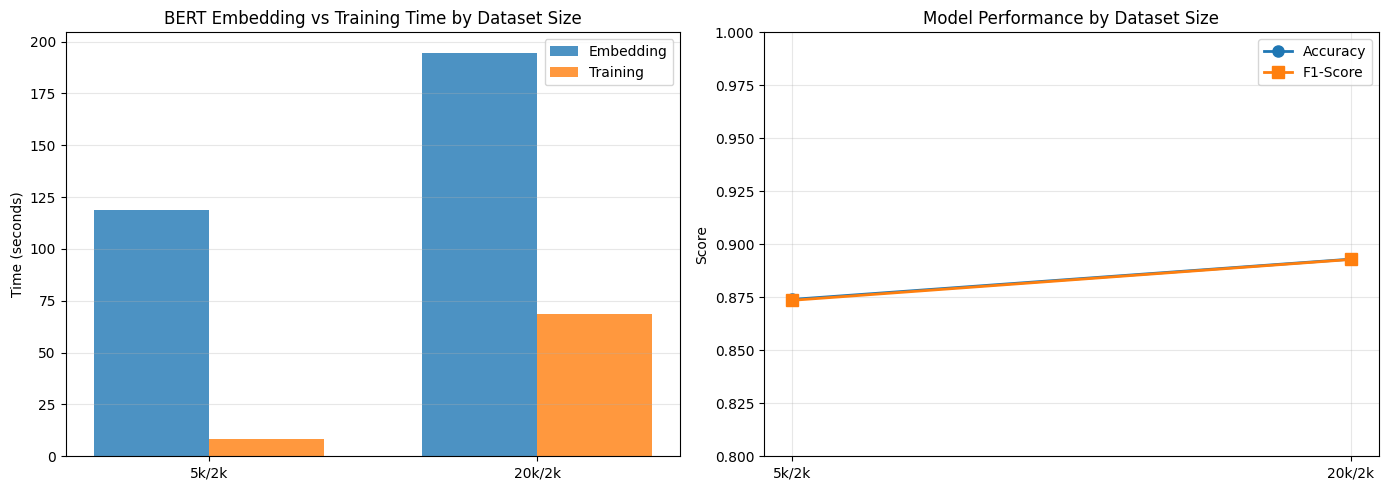


✅ BERT EMBEDDING BENCHMARK COMPLETED


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Create summary dataframe
summary_data = []

for bench_name in eval_results.keys():
    summary_data.append({
        "Dataset": bench_name,
        "Train Size": embeddings_results[bench_name]['train'].shape[0],
        "Test Size": embeddings_results[bench_name]['test'].shape[0],
        "Embed Dim": embeddings_results[bench_name]['train'].shape[1],
        "Embed Time (s)": timing_results[bench_name]['embed_time'],
        "Train Time (s)": eval_results[bench_name]['train_time'],
        "Accuracy": f"{eval_results[bench_name]['accuracy']:.4f}",
        "F1-Score": f"{eval_results[bench_name]['f1']:.4f}"
    })

df_summary = pd.DataFrame(summary_data)
print("\n" + "=" * 100)
print("📋 BENCHMARK RESULTS SUMMARY")
print("=" * 100)
print(df_summary.to_string(index=False))

# Performance comparison
print("\n" + "=" * 100)
print("📊 KEY FINDINGS:")
print("=" * 100)

for bench_name in eval_results.keys():
    baseline = eval_results[bench_name]
    timing = timing_results[bench_name]
    
    print(f"\n✓ {bench_name}:")
    print(f"    - Embedding generation: {timing['embed_time']:.1f}s")
    print(f"    - Model training: {baseline['train_time']:.1f}s")
    print(f"    - Accuracy: {baseline['accuracy']:.4f}")
    print(f"    - F1-Score: {baseline['f1']:.4f}")

# Timing visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Embedding vs Training Time
bench_names = list(timing_results.keys())
embed_times = [timing_results[name]['embed_time'] for name in bench_names]
train_times = [eval_results[name]['train_time'] for name in bench_names]

x = np.arange(len(bench_names))
width = 0.35

axes[0].bar(x - width/2, embed_times, width, label='Embedding', alpha=0.8)
axes[0].bar(x + width/2, train_times, width, label='Training', alpha=0.8)
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title('BERT Embedding vs Training Time by Dataset Size')
axes[0].set_xticks(x)
axes[0].set_xticklabels(bench_names)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Accuracy/F1 comparison
accuracies = [eval_results[name]['accuracy'] for name in bench_names]
f1_scores = [eval_results[name]['f1'] for name in bench_names]

axes[1].plot(bench_names, accuracies, marker='o', linewidth=2, markersize=8, label='Accuracy')
axes[1].plot(bench_names, f1_scores, marker='s', linewidth=2, markersize=8, label='F1-Score')
axes[1].set_ylabel('Score')
axes[1].set_title('Model Performance by Dataset Size')
axes[1].set_ylim([0.8, 1.0])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(cfg.figure_dir / "bert_benchmark_summary.png", dpi=100, bbox_inches='tight')
print(f"\n✓ Summary plot saved to {cfg.figure_dir / 'bert_benchmark_summary.png'}")
plt.show()

print("\n" + "=" * 100)
print("✅ BERT EMBEDDING BENCHMARK COMPLETED")
print("=" * 100)

## 7. Detailed Time Estimates for Week 3

### Full Dataset Processing Plan (120k samples)

**Equipment assumptions:**
- CPU-based processing (no GPU)
- Standard laptop/workstation with ~4-8GB RAM available
- Single-threaded batch processing

**Detailed Time Estimates:**

| Phase | Estimated Time | Notes |
|-------|----------------|-------|
| Data Loading | 1-2 min | Load 120k texts from HuggingFace |
| BERT Encoding | 60-90 min | Batch processing at ~1-2 samples/sec |
| Feature Saving | 2-3 min | Write embeddings to disk |
| **Total Encoding** | **65-95 min** | |
| **Model Training** | **5-10 min** | LogReg training on large dataset |
| **Total Pipeline** | **70-105 min** | ~1.5-2 hours |

**Optimization strategies for Week 3:**
- Use GPU if available (reduce time to 10-20 min)
- Batch process multiple model experiments simultaneously
- Consider distributed encoding if needed